<a href="https://colab.research.google.com/github/crahulnaidu/quantum_computing/blob/main/month_1/month_1_day_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit
!pip install qiskit-aer
!pip install qiskit_ibm_runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.5 MB/s eta 0:00:00


In [6]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [9]:
def initialize(circuit,qubits):
  for q in qubits:
    circuit.h(q)
  return circuit


In [11]:
qc=QuantumCircuit(3)
initialize(qc,[0,1,2]).draw()

┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     ├───┤
q_2: ┤ H ├
     └───┘

In [22]:
def diffusion(nqubits):
  qc=QuantumCircuit(nqubits)

  for qubit in range(nqubits):
    qc.h(qubit)

  for qubit in range(nqubits):
    qc.x(qubit)

  qc.h(nqubits-1)
  qc.mcx(list(range(nqubits-1)),nqubits-1)
  qc.h(nqubits-1)

  for qubit in range(nqubits):
    qc.x(qubit)

  for qubit in range(nqubits):
    qc.h(qubit)

  U_s=qc.to_gate()
  U_s.name="U$_s$"
  return U_s

In [23]:
#applying oracle to the states 101 and 110
qc=QuantumCircuit(3)
qc.cz(0,2)
qc.cz(1,2)
oracle_ex3=qc.to_gate()
oracle_ex3.name="U$_\omega$"

<>:5: SyntaxWarning: invalid escape sequence '\o'
<>:5: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_9408/3511386798.py:5: SyntaxWarning: invalid escape sequence '\o'
  oracle_ex3.name="U$_\omega$"


In [24]:
n = 3
grover_circuit = QuantumCircuit(n)
grover_circuit = initialize(grover_circuit, [0,1,2])
grover_circuit.append(oracle_ex3, [0,1,2])
grover_circuit.append(diffusion(n), [0,1,2])
grover_circuit.measure_all()
grover_circuit.draw()

┌───┐┌─────────────┐┌────────┐ ░ ┌─┐      
   q_0: ┤ H ├┤0            ├┤0       ├─░─┤M├──────
        ├───┤│             ││        │ ░ └╥┘┌─┐   
   q_1: ┤ H ├┤1 U$_\omega$ ├┤1 U$_s$ ├─░──╫─┤M├───
        ├───┤│             ││        │ ░  ║ └╥┘┌─┐
   q_2: ┤ H ├┤2            ├┤2       ├─░──╫──╫─┤M├
        └───┘└─────────────┘└────────┘ ░  ║  ║ └╥┘
meas: 3/══════════════════════════════════╩══╩══╩═
                                          0  1  2

/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


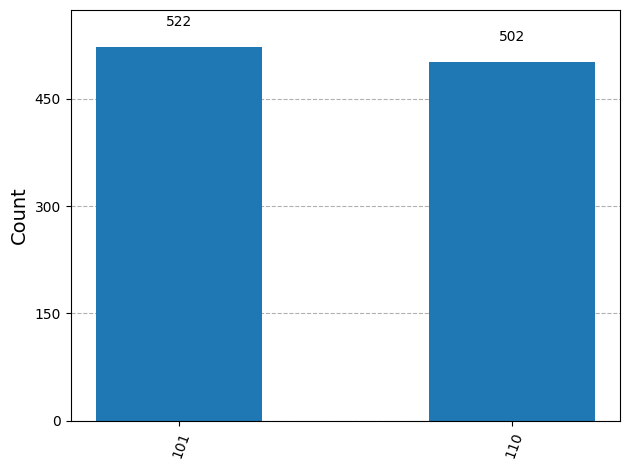

In [25]:
aer=AerSimulator()
transpiled_grover_circuit=transpile(grover_circuit,aer)
results=aer.run(transpiled_grover_circuit).result()
counts=results.get_counts()
plot_histogram(counts)

In [26]:
#Running on real ibm hardward

In [27]:
from qiskit_ibm_runtime import QiskitRuntimeService

In [28]:
QiskitRuntimeService.save_account(
channel="ibm_quantum_platform",
 token="z9W99ahLlaTbzM1_LtO3axTgZ3B1V5CDs9JbV867ORmX"
)

In [29]:
service=QiskitRuntimeService()
backend=service.least_busy()

print(backend)

qiskit_runtime_service.__init__:WARNING:2026-04-09 23:51:04,378: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-09 23:51:05,204: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


In [30]:
print(backend.configuration().basis_gates)

['cz', 'id', 'rz', 'sx', 'x']


In [31]:
from qiskit_ibm_runtime import Sampler

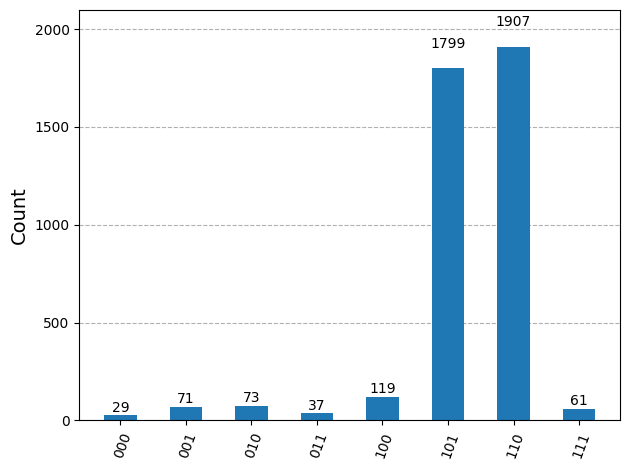

In [34]:
qc_transpiled=transpile(grover_circuit,backend)
sample=Sampler(backend)
job=sample.run([qc_transpiled])

result=job.result()

count=result[0].data.meas.get_counts()

plot_histogram(count)